## 0 Initialization

In [37]:
import json
import pandas as pd
from datetime import datetime

from typing import TypedDict, Dict, Any, List

from langgraph.graph import StateGraph, END
from langgraph.types import Command, interrupt
from langchain_ollama import ChatOllama

In [38]:
# Initialize the Ollama model
model = ChatOllama(
    model="llama3.2:latest",
    temperature=0.1,  # Low temperature for consistent analysis
    base_url="http://host.docker.internal:11434",
)

## 1 mock data

In [21]:

dqc_alert = {
        "severity": "CRITICAL",
        "check_type": "report_readiness_check", 
        "table": "daily_transaction_report",
        "time_period": "2025-06-01T02:53:32.136584",
        "expected_value": "READY",
        "actual_value": "NOT_READY"
    }
with open('table_metadata_20250601_045332.json', 'r') as f:
    TABLE_METADATA = json.load(f)

with open('airflow_logs_20250601_045332.json', 'r') as f:
    AIRFLOW_LOGS  = json.load(f)

with open('dqc_logs_20250601_045332.json', 'r') as f:
    DQC_LOGS = json.load(f)

In [12]:
table_metadata

{'daily_transaction_report': {'table_info': {'database': 'reporting_db',
   'table_name': 'daily_transaction_report',
   'description': 'Daily aggregated transaction report with merchant and payment details',
   'owner': 'data_engineering_team',
   'created_date': '2023-01-15',
   'last_modified': '2025-05-31T22:53:32.136584'},
  'schema': {'columns': [{'name': 'transaction_date',
     'type': 'DATE',
     'nullable': False,
     'description': 'Date of transactions'},
    {'name': 'merchant_id',
     'type': 'VARCHAR(50)',
     'nullable': False,
     'description': 'Unique merchant identifier'},
    {'name': 'total_amount',
     'type': 'DECIMAL(15,2)',
     'nullable': False,
     'description': 'Total transaction amount for the day'},
    {'name': 'transaction_count',
     'type': 'BIGINT',
     'nullable': False,
     'description': 'Number of transactions'},
    {'name': 'success_rate',
     'type': 'DECIMAL(5,2)',
     'nullable': True,
     'description': 'Success rate percenta

In [22]:
# eda
import pandas as pd
pd.set_option('display.max_columns', None)      # Show all columns
pd.set_option('display.max_rows', None)         # Show all rows
pd.set_option('display.max_colwidth', None)     # No column width truncation


table = pd.DataFrame(table_metadata)
table

,daily_transaction_report,daily_summary_report
table_info,"{'database': 'reporting_db', 'table_name': 'daily_transaction_report', 'description': 'Daily aggregated transaction report with merchant and payment details', 'owner': 'data_engineering_team', 'created_date': '2023-01-15', 'last_modified': '2025-05-31T22:53:32.136584'}","{'database': 'reporting_db', 'table_name': 'daily_summary_report', 'description': 'High-level daily summary metrics for business monitoring', 'owner': 'business_intelligence_team', 'created_date': '2023-01-15', 'last_modified': '2025-06-01T01:53:32.136584'}"
schema,"{'columns': [{'name': 'transaction_date', 'type': 'DATE', 'nullable': False, 'description': 'Date of transactions'}, {'name': 'merchant_id', 'type': 'VARCHAR(50)', 'nullable': False, 'description': 'Unique merchant identifier'}, {'name': 'total_amount', 'type': 'DECIMAL(15,2)', 'nullable': False, 'description': 'Total transaction amount for the day'}, {'name': 'transaction_count', 'type': 'BIGINT', 'nullable': False, 'description': 'Number of transactions'}, {'name': 'success_rate', 'type': 'DECIMAL(5,2)', 'nullable': True, 'description': 'Success rate percentage'}, {'name': 'status', 'type': 'VARCHAR(20)', 'nullable': False, 'description': 'Report readiness status (READY/NOT_READY)'}, {'name': 'last_updated_timestamp', 'type': 'TIMESTAMP', 'nullable': False, 'description': 'Last update timestamp'}, {'name': 'data_sources', 'type': 'ARRAY<STRING>', 'nullable': True, 'description': 'List of source systems used'}], 'partitions': ['transaction_date'], 'primary_key': ['transaction_date', 'merchant_id']}","{'columns': [{'name': 'report_date', 'type': 'DATE', 'nullable': False, 'description': 'Date of the report'}, {'name': 'total_volume', 'type': 'DECIMAL(18,2)', 'nullable': False, 'description': 'Total transaction volume'}, {'name': 'total_transactions', 'type': 'BIGINT', 'nullable': False, 'description': 'Total number of transactions'}, {'name': 'unique_merchants', 'type': 'INTEGER', 'nullable': False, 'description': 'Number of unique merchants'}, {'name': 'success_rate', 'type': 'DECIMAL(5,2)', 'nullable': False, 'description': 'Overall success rate'}, {'name': 'error_count', 'type': 'BIGINT', 'nullable': False, 'description': 'Total number of errors'}, {'name': 'avg_transaction_amount', 'type': 'DECIMAL(10,2)', 'nullable': True, 'description': 'Average transaction amount'}, {'name': 'last_updated_timestamp', 'type': 'TIMESTAMP', 'nullable': False, 'description': 'Last update timestamp'}, {'name': 'data_quality_score', 'type': 'DECIMAL(3,1)', 'nullable': True, 'description': 'Data quality score (0-10)'}], 'partitions': ['report_date'], 'primary_key': ['report_date']}"
data_lineage,"{'upstream_dependencies': [{'source': 'raw_transactions', 'database': 'transaction_db', 'update_frequency': 'real-time', 'critical': True}, {'source': 'merchant_data', 'database': 'master_data_db', 'update_frequency': 'daily', 'critical': True}], 'downstream_consumers': ['daily_summary_report', 'business_dashboard', 'regulatory_reports']}","{'upstream_dependencies': [{'source': 'daily_transaction_report', 'database': 'reporting_db', 'update_frequency': 'twice daily', 'critical': True}, {'source': 'error_logs', 'database': 'monitoring_db', 'update_frequency': 'real-time', 'critical': False}], 'downstream_consumers': ['executive_dashboard', 'automated_reports', 'alerting_system']}"
sla_requirements,"{'update_schedule': ['06:00', '18:00'], 'max_delay_tolerance': '2 hours', 'data_freshness_requirement': '1 hour', 'availability_target': '99.5%'}","{'update_schedule': ['07:00', '19:00'], 'max_delay_tolerance': '3 hours', 'data_freshness_requirement': '2 hours', 'availability_target': '99.9%'}"
sample_data,"[{'transaction_date': '2025-06-01', 'merchant_id': 'MERCH001', 'total_amount': 125480.5, 'transaction_count': 1250, 'success_rate': 98.4, 'status': 'NOT_READY', 'last_updated_timestamp': '2025-06-01T00:53:32.136584', 'data_sources': ['raw_transactions']}]","[{'report_d

## 2.0 Agent func

In [40]:
# State definition
class IncidentState(TypedDict):
    alert: Dict[str, Any]
    table_context: Dict[str, Any] 
    related_logs: List[Dict[str, Any]]
    llm_analysis: Dict[str, Any]
    human_review: Dict[str, Any]
    final_recommendation: Dict[str, Any]
    # analysis: Dict[str, Any]
    # root_cause: Dict[str, Any]

In [41]:
# node 1
def get_table_context(state: IncidentState) -> IncidentState:
    print("🔍 NODE 1: Getting table context and data lineage...")
    
    alert = state["alert"]
    table_name = alert.get('table')
    print(f"alert: {alert}, table_name: {table_name}")
    
    if table_name not in TABLE_METADATA:
        print(f"   ❌ Table {table_name} not found in metadata")
        state["table_context"] = {"error": f"Table {table_name} not found"}
        return state
    
    table_info = TABLE_METADATA[table_name]
    
    context = {
        "table_name": table_name,
        "database": table_info['table_info']['database'],
        "owner": table_info['table_info']['owner'],
        "description": table_info['table_info']['description'],
        "upstream_dependencies": table_info['data_lineage']['upstream_dependencies'],
        "downstream_consumers": table_info['data_lineage']['downstream_consumers'],
        "sla_requirements": table_info['sla_requirements'],
    }
    
    print(f"   ✅ Found metadata for table: {table_name}")
    print(f"   ✅ Upstream deps: {[dep['source'] for dep in context['upstream_dependencies']]}")
    print(context)
    
    state["table_context"] = context
    return state

In [43]:
# node 2
def get_related_logs(state: IncidentState) -> IncidentState:
    print("\n📋 NODE 2: Getting related Airflow logs...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    print("."* 100)
    print(f"alert: {alert}, table_context: {table_context}")
    
    if "error" in table_context:
        state["related_logs"] = []
        return state
    
    table_name = alert.get('table')
    alert_time = alert.get('time_period', '')
    alert_date = alert_time.split('T')[0] if alert_time else '2025-06-01'
    
    upstream_sources = [dep['source'] for dep in table_context.get('upstream_dependencies', [])]
    
    print(f"   🔍 Looking for logs related to: {table_name}")
    print(f"   🔍 And upstream dependencies: {upstream_sources}")
    print(f"   🔍 Around date: {alert_date}")
    
    related_logs = []
    
    for log in AIRFLOW_LOGS:
        log_time = log.get('timestamp', '')
        dag_id = log.get('dag_id', '')
        message = log.get('message', '')
        task_id = log.get('task_id', '')
        
        # Check if log is relevant
        is_relevant = False
        
        # 1. Must be from the same date
        if alert_date in log_time:
            # 2. Check if related to our table or its dependencies
            if (table_name.replace('_', '-') in dag_id or
                'transaction' in dag_id or  # Related pipeline
                any(source in message.lower() for source in upstream_sources) or
                any(source in task_id.lower() for source in upstream_sources)):
                is_relevant = True

        if is_relevant:
            related_logs.append(log)
    
    related_logs.sort(key=lambda x: x.get('timestamp', ''))
    print(f"   ✅ Found {len(related_logs)} related logs")
    
    state["related_logs"] = related_logs
    return state

In [53]:
# node 3
def call_llm_analysis(state: IncidentState) -> IncidentState:
    """
    Node 3: Use LLM to analyze the incident context and logs
    """
    print("\n🤖 NODE 3: LLM Analysis and Reasoning...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    related_logs = state["related_logs"]
    # Prepare context for LLM
    context_prompt = f"""
You are an expert data engineer analyzing a critical incident. Please analyze the following information and provide insights:

INCIDENT ALERT:
- Severity: {alert.get('severity')}
- Check Type: {alert.get('check_type')}
- Table: {alert.get('table')}
- Expected Value: {alert.get('expected_value')}
- Actual Value: {alert.get('actual_value')}
- Time: {alert.get('time_period')}

TABLE CONTEXT:
- Table: {table_context.get('table_name')}
- Database: {table_context.get('database')}
- Owner: {table_context.get('owner')}
- Description: {table_context.get('description')}
- Upstream Dependencies: {[dep['source'] for dep in table_context.get('upstream_dependencies', [])]}
- Downstream Consumers: {table_context.get('downstream_consumers')}

RELATED AIRFLOW LOGS ({len(related_logs)} entries):
"""
    # Add log details (limit to most relevant ones)
    error_logs = [log for log in related_logs if log.get('level') == 'ERROR']
    warning_logs = [log for log in related_logs if log.get('level') == 'WARNING']
    
    context_prompt += f"\nERROR LOGS ({len(error_logs)}):\n"
    for i, log in enumerate(error_logs[:5], 1):  # Top 5 errors
        context_prompt += f"{i}. [{log.get('timestamp')}] {log.get('component')} - {log.get('task_id')}\n"
        context_prompt += f"   Message: {log.get('message')}\n\n"
    
    context_prompt += f"\nWARNING LOGS ({len(warning_logs)}):\n"
    for i, log in enumerate(warning_logs[:3], 1):  # Top 3 warnings
        context_prompt += f"{i}. [{log.get('timestamp')}] {log.get('component')} - {log.get('task_id')}\n"
        context_prompt += f"   Message: {log.get('message')}\n\n"
    
    analysis_prompt = context_prompt + """
Please provide a structured analysis with the following:

1. ROOT CAUSE ANALYSIS:
   - What is the most likely root cause?
   - What evidence supports this conclusion?
   - Confidence level (1-10)

2. TIMELINE RECONSTRUCTION:
   - Key events leading to the failure
   - Critical decision points

3. IMPACT ASSESSMENT:
   - Immediate impact on data pipeline
   - Downstream systems affected
   - Business impact severity

4. RECOMMENDATIONS:
   - Immediate actions to resolve
   - Preventive measures for future
   - Monitoring improvements

5. ESCALATION DECISION:
   - Should this be escalated to senior engineers?
   - Required skill sets for resolution

Please be specific and actionable in your recommendations.
"""
    try:
        # Call LLM for analysis
        print("   🔄 Sending context to LLM...")
        response = model.invoke(analysis_prompt)
        print("\n")
        print(response)
        
        llm_analysis = {
            "timestamp": json.dumps(alert.get('time_period')),
            "prompt_used": analysis_prompt,
            "llm_response": response.content,
            "model_used": "llama3.2:latest",
            "context_size": len(analysis_prompt),
            "logs_analyzed": len(related_logs)
        }
        
        print(f"   ✅ LLM analysis completed")
        print(f"   ✅ Response length: {len(response.content)} characters")
        print(f"   ✅ Context analyzed: {len(related_logs)} logs")
        
    except Exception as e:
        print(f"   ❌ LLM analysis failed: {str(e)}")
        llm_analysis = {
            "error": str(e),
            "fallback_message": "LLM analysis unavailable - using rule-based analysis"
        }
    
    state["llm_analysis"] = llm_analysis
    return state

In [71]:
# Node 4: Human Review with Interrupt
def human_review_node(state: IncidentState) -> IncidentState:
    """
    Node 4: Human-in-the-loop evaluation of LLM analysis
    """
    print("\n👤 NODE 4: Human Review (Interrupt)...")
    
    llm_analysis = state["llm_analysis"]
    alert = state["alert"]
    
    # Show LLM analysis for review
    print("📊 LLM ANALYSIS FOR REVIEW:")
    print("-" * 50)
    if llm_analysis.get('llm_response'):
        print(llm_analysis['llm_response'])
    else:
        print("No LLM analysis available")
    print("-" * 50)
    
    # Human interrupt for review
    human_review = interrupt({
        "question": "Please review the analysis and provide feedback",
        "llm_analysis": llm_analysis.get('llm_response', ''),
        "table": alert.get('table'),
        "severity": alert.get('severity')
    })
    
    print(f"Human review received: {human_review.get('action', 'unknown')}")
    
    # Store human review with all feedback
    state["human_review"] = {
        "action": human_review.get("action", "approve"),
        "feedback": human_review.get("feedback", ""),
        "root_cause_override": human_review.get("root_cause", ""),
        "impact_override": human_review.get("impact", ""),
        "business_impact_override": human_review.get("business_impact", ""),
        "decision_points": human_review.get("decision_points", ""),
        "recommendations_override": human_review.get("recommendations", "")
    }
    
    return state

In [47]:
# from typing_extensions import Literal

# def human_review_node(state: IncidentState) -> Command[Literal["finalize_recommendation", "call_llm_analysis"]]:
#     """
#     Node 4: Human-in-the-loop evaluation of LLM analysis
#     """
#     print("\n👤 NODE 4: Human Review (Interrupt)...")
    
#     llm_analysis = state["llm_analysis"]
#     alert = state["alert"]
    
#     # Prepare review context for human
#     review_context = {
#         "incident_summary": {
#             "table": alert.get('table'),
#             "severity": alert.get('severity'),
#             "issue": f"{alert.get('expected_value')} vs {alert.get('actual_value')}"
#         },
#         "llm_analysis_preview": llm_analysis.get('llm_response', 'N/A')[:500] + "..." if llm_analysis.get('llm_response') else "No analysis available",
#         "logs_count": len(state.get('related_logs', [])),
#         "upstream_deps": [dep['source'] for dep in state['table_context'].get('upstream_dependencies', [])]
#     }
    
#     # Human interrupt for review
#     human_review = interrupt({
#         "question": "Please review the LLM analysis. Is it accurate and actionable?",
#         "context": review_context,
#         "options": {
#             "approve": "Analysis looks good - proceed with recommendations",
#             "modify": "Analysis needs modification - provide feedback",
#             "retry": "Re-run LLM analysis with different approach",
#             "escalate": "Escalate to senior engineer"
#         }
#     })
    
#     print(f"Human review decision: {human_review}")
    
#     # Store human review
#     state["human_review"] = {
#         "timestamp": json.dumps(alert.get('time_period')),
#         "decision": human_review.get("action", "unknown"),
#         "feedback": human_review.get("feedback", ""),
#         "reviewer_notes": human_review.get("notes", "")
#     }
    
#     # Route based on human decision
#     decision = human_review.get("action", "approve")
    
#     if decision == "retry":
#         print("   🔄 Human requested LLM retry")
#         return Command(goto="call_llm_analysis")
#     else:
#         print("   ✅ Proceeding to finalize recommendations")
#         return Command(goto="finalize_recommendation")

In [72]:
# noed 5
def finalize_recommendation(state: IncidentState) -> IncidentState:
    """
    Node 5: Create final recommendation based on LLM analysis and human review
    """
    print("\n🎯 NODE 5: Finalizing Recommendations...")
    
    alert = state["alert"]
    llm_analysis = state["llm_analysis"]
    human_review = state["human_review"]
    
    final_recommendation = {
        "incident_id": f"INC-{alert.get('table')}-{alert.get('time_period', '').replace(':', '').replace('-', '')}",
        "timestamp": alert.get('time_period'),
        "status": "analyzed",
        "analysis_method": "llm_with_human_review",
        "llm_analysis_summary": llm_analysis.get('llm_response', 'N/A')[:200] + "..." if llm_analysis.get('llm_response') else "No LLM analysis",
        "human_review_decision": human_review.get('decision', 'unknown'),
        "human_feedback": human_review.get('feedback', ''),
        "next_steps": [],
        "escalation_required": human_review.get('decision') == 'escalate'
    }
    
    # Extract next steps based on human decision
    if human_review.get('decision') == 'approve':
        final_recommendation["next_steps"] = [
            "Execute LLM recommended actions",
            "Monitor resolution progress",
            "Update incident status"
        ]
    elif human_review.get('decision') == 'modify':
        final_recommendation["next_steps"] = [
            "Implement human-suggested modifications",
            "Re-validate approach",
            "Execute modified plan"
        ]
    elif human_review.get('decision') == 'escalate':
        final_recommendation["next_steps"] = [
            "Escalate to senior engineering team",
            "Provide full context and analysis",
            "Await expert guidance"
        ]
    
    print(f"   ✅ Final recommendation created: {final_recommendation['incident_id']}")
    print(f"   ✅ Status: {final_recommendation['status']}")
    print(f"   ✅ Escalation required: {final_recommendation['escalation_required']}")
    
    state["final_recommendation"] = final_recommendation
    return state

In [106]:
def continue_with_routing(paused_state, human_feedback):
    """
    Continue workflow based on human decision with proper routing
    """
    action = human_feedback.get('action', 'approve')
    print(f"🔄 Continuing with decision: {action}")
    
    # Update state with human feedback
    paused_state["human_review"] = human_feedback
    
    if action == 'approve':
        print("✅ APPROVED - Going to final report generation")
        final_result = generate_final_report(paused_state)
        print("✅ Final report generated!")
        return final_result
        
    elif action == 'modify':
        print("📝 MODIFY - Re-running LLM analysis with feedback")
        updated_state = call_llm_analysis(paused_state)
        updated_state["human_review"] = human_feedback  # Keep the human feedback
        final_result = generate_final_report(updated_state)
        print("✅ Modified analysis completed!")
        return final_result
        
    elif action == 'escalate':
        print("🚨 ESCALATE - Creating escalation report")
        final_result = generate_final_report(paused_state)
        print("✅ Escalation report created!")
        return final_result
        
    else:
        print(f"❌ Unknown action: {action}, defaulting to approve")
        final_result = generate_final_report(paused_state)
        return final_result

def generate_final_report(state: IncidentState) -> IncidentState:
    """
    Node 5: Generate final root cause analysis report using LLM + human input
    """
    print("\n📋 NODE 5: Generating Final Root Cause Report...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    llm_analysis = state["llm_analysis"]
    human_review = state["human_review"]
    
    # Use human overrides if provided, otherwise use LLM analysis
    root_cause = human_review.get("root_cause_override") or "Based on LLM analysis"
    impact = human_review.get("impact_override") or "Standard pipeline impact"
    business_impact = human_review.get("business_impact_override") or "Reporting delays"
    
    final_report = {
        "incident_id": f"INC-{alert.get('table')}-{alert.get('time_period', '').replace(':', '').replace('-', '')}",
        "timestamp": alert.get('time_period'),
        "severity": alert.get('severity'),
        "table_affected": alert.get('table'),
        
        # Root cause analysis
        "root_cause_analysis": {
            "primary_cause": root_cause,
            "human_validation": human_review.get('action', 'unknown'),
            "confidence": "High" if human_review.get('action') == 'approve' else "Requires review"
        },
        
        # Impact assessment  
        "impact_assessment": {
            "technical_impact": impact,
            "business_impact": business_impact,
            "downstream_systems": table_context.get('downstream_consumers', [])
        },
        
        # Actions and status
        "recommended_actions": human_review.get("recommendations_override") or "Follow LLM recommendations",
        "status": "analysis_complete",
        "escalation_required": human_review.get('action') == 'escalate',
        "human_feedback": human_review.get('feedback', '')
    }
    
    print(f"   ✅ Final report generated: {final_report['incident_id']}")
    print(f"   ✅ Human decision: {human_review.get('action', 'unknown')}")
    
    state["final_recommendation"] = final_report
    return state

def route_after_human_review(state: IncidentState) -> Literal["call_llm_analysis", "generate_final_report"]:
    """
    Route based on human decision
    """
    human_action = state["human_review"].get("action", "approve")
    
    if human_action == "modify":
        print("   🔄 Routing to: Re-run LLM analysis")
        return "call_llm_analysis"
    else:  # approve or escalate
        print("   ✅ Routing to: Generate final report")
        return "generate_final_report"

In [109]:
workflow = StateGraph(IncidentState)
# Add all four nodes
workflow.add_node("get_table_context", get_table_context)
workflow.add_node("get_related_logs", get_related_logs)
workflow.add_node("call_llm_analysis", call_llm_analysis)
workflow.add_node("human_review_node", human_review_node)
# workflow.add_node("finalize_recommendation", finalize_recommendation)
workflow.add_node("generate_final_report", generate_final_report)

# Set up the flow: start with table context, then get logs
workflow.set_entry_point("get_table_context")
workflow.add_edge("get_table_context", "get_related_logs")
# workflow.add_edge("get_related_logs", END)
workflow.add_edge("get_related_logs", "call_llm_analysis")
workflow.add_edge("call_llm_analysis", "human_review_node")
workflow.add_edge("generate_final_report", END)
workflow.add_conditional_edges(
    "human_review_node",
    route_after_human_review,
    {
        "call_llm_analysis": "call_llm_analysis",  # modify -> re-run LLM
        "generate_final_report": "generate_final_report"  # approve/escalate -> final report
    }
)
workflow.add_edge("generate_final_report", END)
# memory = MemorySaver()

# app = builder.compile(checkpointer=memory)
app = workflow.compile(interrupt_before=["human_review_node"])

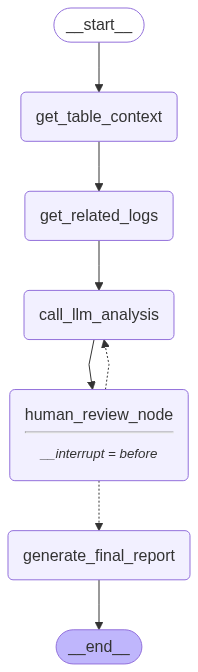

In [110]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [112]:
sample_alert = {
        "severity": "CRITICAL",
        "check_type": "report_readiness_check", 
        "table": "daily_transaction_report",
        "time_period": "2025-06-01T02:53:32.136584",
        "expected_value": "READY",
        "actual_value": "NOT_READY"
    }

In [114]:
# demo approved from human review

initial_state = {
        "alert": sample_alert,
        "table_context": {},
        "related_logs": [],
        "llm_analysis": {},
        "human_review": {},
        "final_recommendation": {}
    }

paused_state  = app.invoke(initial_state)

print("\n🔄 AGENT PAUSED FOR HUMAN REVIEW")
print("=" * 70)
print("Review the analysis and provide feedback...")


🔍 NODE 1: Getting table context and data lineage...
alert: {'severity': 'CRITICAL', 'check_type': 'report_readiness_check', 'table': 'daily_transaction_report', 'time_period': '2025-06-01T02:53:32.136584', 'expected_value': 'READY', 'actual_value': 'NOT_READY'}, table_name: daily_transaction_report
   ✅ Found metadata for table: daily_transaction_report
   ✅ Upstream deps: ['raw_transactions', 'merchant_data']
{'table_name': 'daily_transaction_report', 'database': 'reporting_db', 'owner': 'data_engineering_team', 'description': 'Daily aggregated transaction report with merchant and payment details', 'upstream_dependencies': [{'source': 'raw_transactions', 'database': 'transaction_db', 'update_frequency': 'real-time', 'critical': True}, {'source': 'merchant_data', 'database': 'master_data_db', 'update_frequency': 'daily', 'critical': True}], 'downstream_consumers': ['daily_summary_report', 'business_dashboard', 'regulatory_reports'], 'sla_requirements': {'update_schedule': ['06:00', '18

In [115]:
paused_state 

{'alert': {'severity': 'CRITICAL',
  'check_type': 'report_readiness_check',
  'table': 'daily_transaction_report',
  'time_period': '2025-06-01T02:53:32.136584',
  'expected_value': 'READY',
  'actual_value': 'NOT_READY'},
 'table_context': {'table_name': 'daily_transaction_report',
  'database': 'reporting_db',
  'owner': 'data_engineering_team',
  'description': 'Daily aggregated transaction report with merchant and payment details',
  'upstream_dependencies': [{'source': 'raw_transactions',
    'database': 'transaction_db',
    'update_frequency': 'real-time',
    'critical': True},
   {'source': 'merchant_data',
    'database': 'master_data_db',
    'update_frequency': 'daily',
    'critical': True}],
  'downstream_consumers': ['daily_summary_report',
   'business_dashboard',
   'regulatory_reports'],
  'sla_requirements': {'update_schedule': ['06:00', '18:00'],
   'max_delay_tolerance': '2 hours',
   'data_freshness_requirement': '1 hour',
   'availability_target': '99.5%'}},
 'r

In [118]:
# Step 2: Show LLM analysis
if 'llm_analysis' in paused_state and paused_state['llm_analysis'].get('llm_response'):
    print("\n📊 LLM ANALYSIS:")
    print("-" * 50)
    print(paused_state['llm_analysis']['llm_response'])
    print("-" * 50)



📊 LLM ANALYSIS:
--------------------------------------------------
**ROOT CAUSE ANALYSIS**

Based on the provided information, the most likely root cause of the critical incident is:

1. **Incomplete merchant data extraction**
2. Evidence supporting this conclusion:
	* The first error log from `data_extractor` indicates a connection timeout to the database after 300 seconds, suggesting that the merchant data extraction process failed.
	* The second error log from `check_validator` explicitly states that the upstream data source 'merchant_data' is incomplete, which aligns with the root cause identified above.
3. Confidence level: 9/10

**TIMELINE RECONSTRUCTION**

Key events leading to the failure:

1. **02:28:32**: The `data_extractor` process attempts to extract merchant data from the database but fails due to a connection timeout after 300 seconds.
2. **02:33:32**: The `data_validator` process proceeds with transaction processing without merchant data, marking the report as NOT_READ

In [116]:
print("\n🛑 AGENT PAUSED FOR HUMAN REVIEW")
print("=" * 70)


🛑 AGENT PAUSED FOR HUMAN REVIEW


In [117]:
# simgle scenario test
result = continue_with_routing(paused_state, {
    'action': 'approve',
    'feedback': 'Analysis looks good',
    'root_cause_override': 'Database timeout issue'
})


🔄 Continuing with decision: approve
✅ APPROVED - Going to final report generation

📋 NODE 5: Generating Final Root Cause Report...
   ✅ Final report generated: INC-daily_transaction_report-20250601T025332.136584
   ✅ Human decision: approve
✅ Final report generated!


In [96]:
# Show LLM analysis for review
if 'llm_analysis' in paused_state and paused_state['llm_analysis'].get('llm_response'):
    print("📊 LLM ANALYSIS TO REVIEW:")
    print(paused_state['llm_analysis']['llm_response'])
    print("\n" + "=" * 70)

📊 LLM ANALYSIS TO REVIEW:
**ROOT CAUSE ANALYSIS**

Based on the provided information, the most likely root cause of the critical incident is:

1. **Incomplete merchant data from upstream dependency 'merchant_data'**
	* Evidence: The error log from `check_validator - report_readiness_check` indicates that the upstream data source 'merchant_data' is incomplete, which led to the failure of the report readiness check.
	* Confidence level: 9/10

The incomplete merchant data likely caused the `data_extractor - extract_merchant_data` task to fail due to a connection timeout. This, in turn, triggered the `check_validator - report_readiness_check` task, which failed because it expected the upstream data source to be complete.

**TIMELINE RECONSTRUCTION**

Key events leading to the failure:

1. **2025-06-01T02:28:32.136584**: The `data_extractor - extract_merchant_data` task fails due to a connection timeout, marking the start of the incident.
2. **2025-06-01T02:33:32.136584**: The `data_validat

In [120]:
def get_cli_input() -> Dict[str, Any]:
    """Get human feedback from CLI input"""
    print("\n" + "="*60)
    print("🤖 HUMAN REVIEW REQUIRED")
    print("="*60)
    
    print("\nAvailable actions:")
    print("1. approve - Analysis looks good, proceed")
    print("2. modify - Analysis needs changes")
    print("3. escalate - Send to senior engineers")
    
    # Get action
    while True:
        action = input("\nEnter your decision (approve/modify/escalate): ").strip().lower()
        if action in ['approve', 'modify', 'escalate']:
            break
        print("❌ Invalid action. Please enter: approve, modify, or escalate")
    
    # Get feedback
    feedback = input("Enter your feedback/comments: ").strip()
    
    # Get additional details based on action
    human_input = {
        'action': action,
        'feedback': feedback
    }
    
    if action in ['approve', 'modify']:
        print("\n📝 Provide additional details (press Enter to skip):")
        
        root_cause = input("Root cause override: ").strip()
        if root_cause:
            human_input['root_cause_override'] = root_cause
            
        impact = input("Technical impact: ").strip()
        if impact:
            human_input['impact_override'] = impact
            
        business_impact = input("Business impact: ").strip()
        if business_impact:
            human_input['business_impact_override'] = business_impact
            
        recommendations = input("Recommendations: ").strip()
        if recommendations:
            human_input['recommendations_override'] = recommendations
    
    elif action == 'escalate':
        print("\n🚨 Escalation details:")
        escalation_reason = input("Escalation reason (optional): ").strip()
        if escalation_reason:
            human_input['escalation_reason'] = escalation_reason
    
    return human_input

In [123]:
# try:
human_feedback = get_cli_input()
# except KeyboardInterrupt:
#     print("\n\n❌ Process interrupted by user")
#     return None
# except Exception as e:
#     print(f"\n❌ Error getting input: {e}")
#     return None



🤖 HUMAN REVIEW REQUIRED

Available actions:
1. approve - Analysis looks good, proceed
2. modify - Analysis needs changes
3. escalate - Send to senior engineers



Enter your decision (approve/modify/escalate):  approve
Enter your feedback/comments:  



📝 Provide additional details (press Enter to skip):


Root cause override:  
Technical impact:  
Business impact:  
Recommendations:  


In [125]:
print(f"\n🔄 Processing your decision: {human_feedback['action']}")
try:
    final_result = continue_with_routing(paused_state, human_feedback)
except Exception as e:
    print(f"❌ Error processing decision: {e}")
    raise e


🔄 Processing your decision: approve
🔄 Continuing with decision: approve
✅ APPROVED - Going to final report generation

📋 NODE 5: Generating Final Root Cause Report...
   ✅ Final report generated: INC-daily_transaction_report-20250601T025332.136584
   ✅ Human decision: approve
✅ Final report generated!


In [126]:
print("\n✅ INCIDENT RESOLUTION COMPLETE")
print("=" * 60)

if 'final_recommendation' in final_result:
    final_rec = final_result['final_recommendation']
    print(f"📋 Incident ID: {final_rec.get('incident_id')}")
    print(f"🎯 Root Cause: {final_rec.get('root_cause_analysis', {}).get('primary_cause')}")
    print(f"⚠️  Escalation Required: {final_rec.get('escalation_required')}")
    print(f"📝 Status: {final_rec.get('status')}")
    
    # Save to file
    output_file = f"incident_report_{final_rec.get('incident_id')}.json"
    with open(output_file, 'w') as f:
        json.dump(final_result, f, indent=2)
    print(f"💾 Full report saved to: {output_file}")


✅ INCIDENT RESOLUTION COMPLETE
📋 Incident ID: INC-daily_transaction_report-20250601T025332.136584
🎯 Root Cause: Based on LLM analysis
⚠️  Escalation Required: False
📝 Status: analysis_complete
💾 Full report saved to: incident_report_INC-daily_transaction_report-20250601T025332.136584.json


In [ ]:
# pending to test modify and escalate scenario